## Imports and paths

In [15]:
from config import *
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import aggregate_raters, fleiss_kappa
pd.set_option("display.max_columns", None)  # show all cols
pd.set_option("display.width", None)        # + better readability
from matplotlib.ticker import MultipleLocator


In [16]:
csv_path = RUNS_DATA_DIR / 'responses'
raw_path = RUNS_DATA_DIR / 'raw_responses'
annotations_path = RUNS_DATA_DIR / 'menulink_annotations.csv'
to_label_path = RUNS_DATA_DIR / 'disagreement_to_label.csv'

## Model Cost and Token Usage

### Model Cost in USD 

In [17]:
files = sorted(raw_path.glob('20260917-*'))

dfs = []

for f in files:
    df_raw = pd.read_json(f, lines=True)[['model', 'batch_index', 'usage']]
    dfs.append(df_raw)

raw_df = pd.concat(dfs, ignore_index=True)
# unpack usage column
usage_df = pd.json_normalize(raw_df['usage'])
raw_df = pd.concat([raw_df.drop(columns='usage'), usage_df], axis=1)

raw_df.head()

,model,batch_index,completion_tokens,prompt_tokens,total_tokens,reasoning_tokens,cost,completion_tokens_details.accepted_prediction_tokens,completion_tokens_details.audio_tokens,completion_tokens_details.reasoning_tokens,completion_tokens_details.rejected_prediction_tokens,completion_tokens_details.text_tokens,completion_tokens_details.image_tokens,prompt_tokens_details.audio_tokens,prompt_tokens_details.cache_write_tokens,prompt_tokens_details.cached_tokens,prompt_tokens_details.image_tokens,prompt_tokens_details.text_tokens,prompt_tokens_details.video_tokens,cost_details.upstream_inference_cost,cost_details.upstream_inference_prompt_cost,cost_details.upstream_inference_completions_cost,cost_details.total_cost,cost_details.input_cost,cost_details.output_cost,cost_details.cached_input_cost,cost_details.cache_write_input_cost,cost_details.request_cost,cost_details.web_search_cost,cost_details.image_input_cost,cost_details.image_output_cost,cost_details.audio_input_cost,prompt_tokens_details.cache_creation_tokens
0,anthropic/claude-sonnet-5,0,6787,422164,428951,3342,1.132198,None,0,3342,None,None,0,0,0,0,0,None,0,0.912198,0.844328,0.06787,1.132198,0.844328,0.06787,0.0,0.0,0,0.22,None,None,None,NaN
1,anthropic/claude-sonnet-5,1,5477,528754,534231,1690,1.342278,None,0,1690,None,None,0,0,0,0,0,None,0,1.112278,1.057508,0.05477,1.342278,1.057508,0.05477,0.0,0.0,0,0.23,None,None,None,NaN
2,anthropic/claude-sonnet-5,2,9156,689256,698412,5519,1.710072,None,0,5519,None,None,0,0,0,0,0,None,0,1.470072,1.378512,0.09156,1.710072,1.378512,0.09156,0.0,0.0,0,0.24,None,None,None,NaN
3,anthropic/claude-sonnet-5,3,7346,500708,508054,3612,1.314876,None,0,3612,None,None,0,0,0,0,0,None,0,1.074876,1.001416,0.07346,1.314876,1.001416,0.07346,0.0,0.0,0,0.24,None,None,None,NaN
4,anthropic/claude-sonnet-5,4,9081,711779,720860,4953,1.804368,None,0,4953,None,None,0,0,0,0,0,None,0,1.514368,1.423558,0.09081,1.804368,1.423558,0.09081,0.0,0.0,0,0.29,None,None,None,NaN


In [18]:
# # including sonnet cached for one batch
# sonnet_cache = pd.read_json(raw_path / '20260919-124908-claude-sonnet-5.jsonl', lines=True)[['model', 'batch_index', 'usage']]
# sonnet_usage_df = pd.json_normalize(sonnet_cache['usage'])
# sonnet_cache = pd.concat([sonnet_cache.drop(columns='usage'), sonnet_usage_df], axis=1)

# sonnet_cache['model'] = sonnet_cache['model'].replace({ 'anthropic/claude-sonnet-5': 'anthropic/claude-sonnet-5-cached' }) # keep cached as own entry
# raw_df = pd.concat([sonnet_cache, raw_df], axis=0)
# raw_df

In [19]:
# gemini ran through two providers (google-vertex + google-ai-studio) -> strip the provider prefix so they're grouped together
raw_df['model_name'] = raw_df['model'].str.split('/').str[1]

# one row per batch call -> sum the cost of all batches per model
model_price = raw_df.groupby('model_name').agg(n_batches=('batch_index', 'nunique'), total_cost=('cost', 'sum'))
model_price.head()

,n_batches,total_cost
model_name,,
claude-sonnet-5,22,29.838944
gemini-3.7-flash,22,3.862064
gpt-5.6-luna,22,2.832598
gpt-5.6-terra,22,8.526132


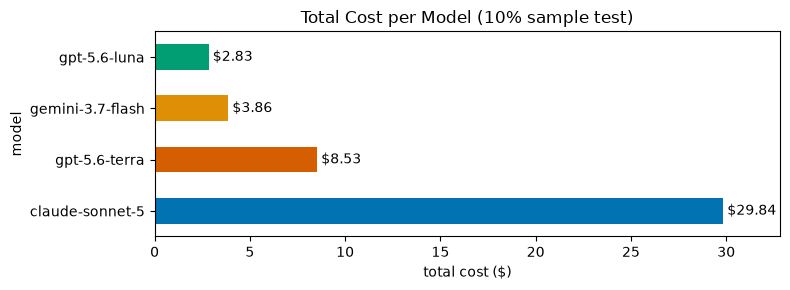

In [20]:
# model_price_fairplot = model_price.drop(index='claude-sonnet-5-cached')
model_price['estimated_full_cost'] = model_price['total_cost'] * 10 # calculate estimated full price

# descending, since barh draws the first row at the bottom -> cheapest on top
plot_df = model_price.sort_values('total_cost', ascending=False)
n_models = len(model_price.index)
colors = sns.color_palette('colorblind', n_colors=n_models)
# tie each color to a model name (alphabetical, like the annotation plots) so sorting by cost doesn't reshuffle colors
model_colors = dict(zip(model_price.index, colors))

ax = plot_df['total_cost'].plot(kind='barh', color=[model_colors[m] for m in plot_df.index], figsize=(8, 3))
ax.bar_label(ax.containers[0], fmt='$%.2f', padding=3)

ax.set_xlabel('total cost ($)')
ax.set_ylabel('model')
ax.set_title(f'Total Cost per Model (10% sample test)')
ax.margins(x=0.1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'total-cost-per-model-10%.svg')
plt.show()

### Model Tokens

In [21]:
model_tokens = raw_df.groupby('model_name').agg(n_batches=('batch_index', 'nunique'), total_tokens=('total_tokens', 'sum'))
model_tokens.head()

,n_batches,total_tokens
model_name,,
claude-sonnet-5,22,11802600
gemini-3.7-flash,22,264219
gpt-5.6-luna,22,1944404
gpt-5.6-terra,22,2393997


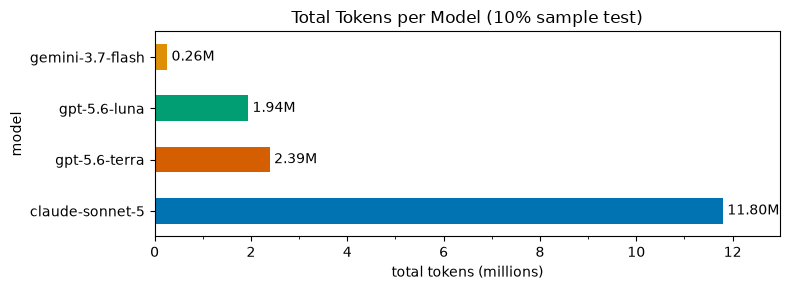

In [22]:
# descending, since barh draws the first row at the bottom -> fewest tokens on top
plot_df = model_tokens.sort_values('total_tokens', ascending=False)
n_models = len(model_tokens.index)
colors = sns.color_palette('colorblind', n_colors=n_models)
# tie each color to a model name (alphabetical, like the annotation plots) so sorting doesn't reshuffle colors
model_colors = dict(zip(model_tokens.index, colors))

# show in millions: keeps the linear scale (bar length = real ratio) but readable numbers
ax = (plot_df['total_tokens'] / 1e6).plot(kind='barh', color=[model_colors[m] for m in plot_df.index], figsize=(8, 3))
ax.bar_label(ax.containers[0], fmt='%.2fM', padding=3)

ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.set_xlabel('total tokens (millions)')
ax.set_ylabel('model')
ax.set_title(f'Total Tokens per Model (10% sample test)')
ax.margins(x=0.1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'total-tokens-pr-model-10%.svg')
plt.show()

## Load model answers

One row per restaurant and model.

`hasFoundMenu` is always consistent with `menuLink`, so we use `hasFoundMenu` as the binary label.

In [23]:
files = sorted(csv_path.glob('20260917-*'))

dfs = []
for f in files:
    df = pd.read_csv(f, usecols=['model', 'input', 'answer'])
    answer = pd.json_normalize(df['answer'].apply(json.loads))
    # websiteUri is only in the input we sent to the model
    answer['websiteUri'] = df['input'].apply(lambda s: json.loads(s).get('websiteUri'))
    answer['model'] = df['model'].str.split('/').str[1]
    dfs.append(answer)

df = pd.concat(dfs, ignore_index=True)
df.head()


,id,name,hasFoundMenu,menuLink,format,source,websiteUri,model
0,ChIJAV1_vX1SUkYRifHQGs0-33o,Pizze Di Napo Hellerup,True,https://pizzedinapohellerup.dk/,HTML,OFFICIAL_WEBSITE,https://platia.dk/pizze-di-napo-hellerup,claude-sonnet-5
1,ChIJ7RIaXXpQUkYRxGD3xBRRltk,McDonald's,True,https://www.mcdonalds.com/dk/da-dk/vores-menu....,HTML,OFFICIAL_WEBSITE,https://www.mcdonalds.com/dk/da-dk/location/ba...,claude-sonnet-5
2,ChIJq6p-9w9TUkYRGJ7PByHSDYY,Byens Pizza,True,http://byens-pizza.dk/?page_id=2065,HTML,OFFICIAL_WEBSITE,http://byens-pizza.dk/?page_id=2065,claude-sonnet-5
3,ChIJz3lHpeRSUkYRRNH0_-MSMhU,Restaurant Taormina v/Mukuntharaj Karunaratnam,True,https://taormina.dk/menu/,HTML,OFFICIAL_WEBSITE,https://taormina.dk/,claude-sonnet-5
4,ChIJBVGBtQFTUkYR7R1FSqjW1kg,Barnetsfest,False,,,,http://www.barnetsfest.dk/,claude-sonnet-5


### Restaurant IDs and menu found

Pivot the table, so that we get the dataframe by whether or not a menu was found, with each model as its own column.

In [24]:
found = df.pivot_table(index='id', columns='model', values='hasFoundMenu', aggfunc='first').astype(bool)
models = list(found.columns)

print(f"{len(found)} restaurants, {len(models)} models: {models}")
found.head()

439 restaurants, 4 models: ['claude-sonnet-5', 'gemini-3.7-flash', 'gpt-5.6-luna', 'gpt-5.6-terra']


model,claude-sonnet-5,gemini-3.7-flash,gpt-5.6-luna,gpt-5.6-terra
id,,,,
ChIJ-7iMbc1TUkYR066Hz1SQ-EI,True,True,True,True
ChIJ-QrW55VTUkYRiO5rYIpA5PE,True,True,True,True
ChIJ-XF3Wu1TUkYRl25fQ2IL8Ps,True,True,True,True
ChIJ-YewRThSUkYRU-ZX1KiCAr0,True,True,True,True
ChIJ-ao52_ZNUkYRU11OTne3ec8,True,True,True,True


### How many models said "found"?

For each restaurant, we want to figure out for how many restaurants, all four models agreed. This gives us an overall view of how many entries were ambigous.

- 0 and 4 means that either *no* model found a menu or *all* models found a menu. This gives us a somewhat confidence in that they agree that this restaurant had a menu.
- On the other hand, 1, 2, 3 are ambigous, since we don't have a ground truth.

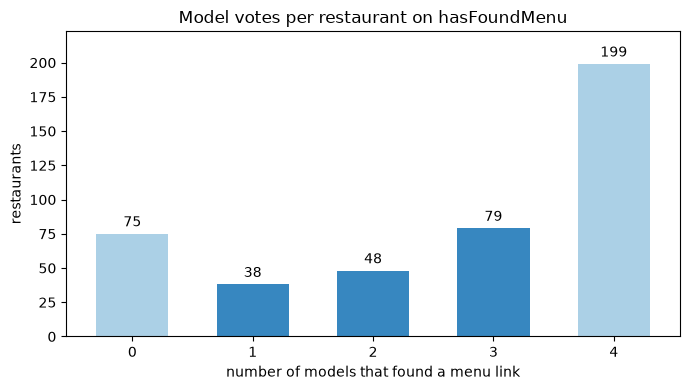

Unanimous: 274/439 (62.4%)


In [29]:
votes = found.sum(axis=1)
vote_counts = votes.value_counts().sort_index()

# unanimous (0 or 4) in a lighter blue, splits in the darker one
blues = sns.color_palette('Blues', 5)
bar_colors = [blues[1] if n in (0, len(models)) else blues[3] for n in vote_counts.index]

ax = vote_counts.plot(kind='bar', color=bar_colors, width=0.6, figsize=(7, 4))
ax.bar_label(ax.containers[0], padding=3)
ax.set_xlabel('number of models that found a menu link')
ax.set_ylabel('restaurants')
ax.set_title('Model votes per restaurant on hasFoundMenu')
ax.tick_params(axis='x', rotation=0)
ax.margins(y=0.12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'hasfoundmenu-votes-per-restaurant-10%.svg')
plt.show()

n_unanimous = vote_counts.get(0, 0) + vote_counts.get(len(models), 0)
print(f"Unanimous: {n_unanimous}/{len(found)} ({n_unanimous / len(found):.1%})")

This leavus us with **165** restaurant IDs that are ambigous, which we would have to manually check.

## Pairwise agreement

- **Percent agreement**: share of restaurants where both models give the same answer.
- **Cohen's kappa**: same, but corrected for the agreement you'd expect by chance given how often each model says "found". Since most restaurants have a menu, two models that both say "found" a lot will agree often by pure chance, so kappa is the fairer number.

Rough reading of kappa (Landis & Koch): < 0.2 slight, 0.2-0.4 fair, 0.4-0.6 moderate, 0.6-0.8 substantial, > 0.8 almost perfect.

In [26]:
pct_agreement = pd.DataFrame(1.0, index=models, columns=models)
cohen = pd.DataFrame(1.0, index=models, columns=models)

for model_1, model_2 in combinations(models, 2):
    pct = (found[model_1] == found[model_2]).mean()
    k = cohen_kappa_score(found[model_1], found[model_2])
    pct_agreement.loc[model_1, model_2] = pct_agreement.loc[model_2, model_1] = pct
    cohen.loc[model_1, model_2] = cohen.loc[model_2, model_1] = k

pd.concat({'percent agreement': pct_agreement, "cohen's kappa": cohen}, axis=1).round(3)

percent agreement                                \
                   claude-sonnet-5 gemini-3.7-flash gpt-5.6-luna   
claude-sonnet-5              1.000            0.763        0.749   
gemini-3.7-flash             0.763            1.000        0.809   
gpt-5.6-luna                 0.749            0.809        1.000   
gpt-5.6-terra                0.747            0.861        0.834   

                                 cohen's kappa                                \
                 gpt-5.6-terra claude-sonnet-5 gemini-3.7-flash gpt-5.6-luna   
claude-sonnet-5          0.747           1.000            0.491        0.478   
gemini-3.7-flash         0.861           0.491            1.000        0.558   
gpt-5.6-luna             0.834           0.478            0.558        1.000   
gpt-5.6-terra            1.000           0.463            0.653        0.624   

                                
                 gpt-5.6-terra  
claude-sonnet-5          0.463  
gemini-3.7-flash         0.653  
gpt-5.6-luna             0.624  
gpt-5.6-terra            1.000

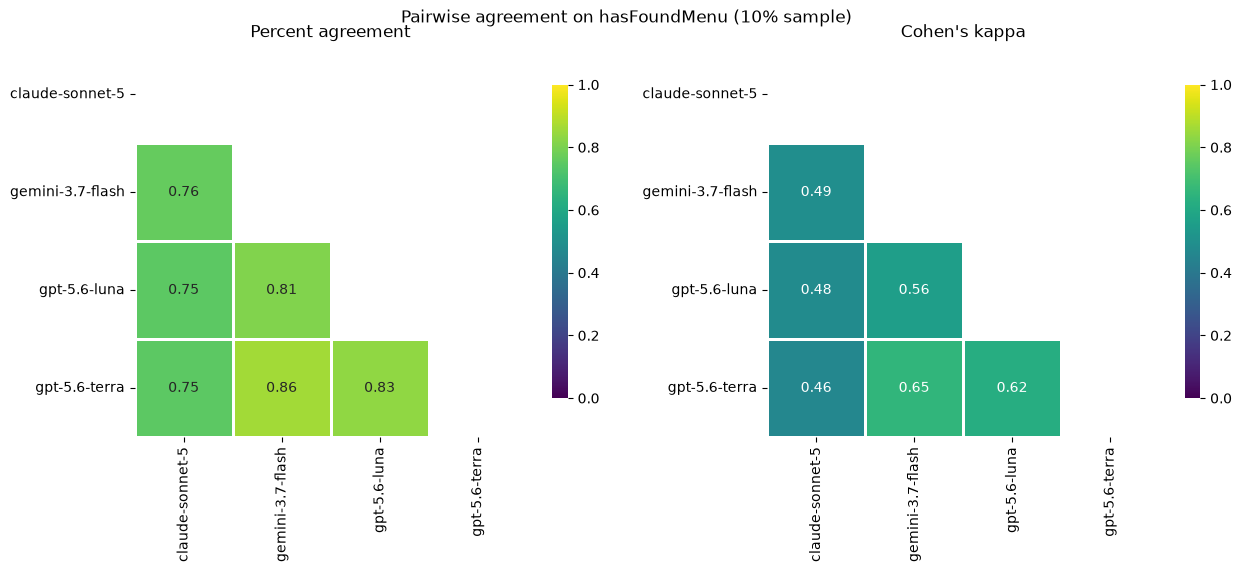

In [27]:
# upper triangle is a mirror of the lower one -> hide it (keep the diagonal off too, it is always 1)
mask = np.triu(np.ones_like(cohen, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, matrix, title in zip(axes, [pct_agreement, cohen], ['Percent agreement', "Cohen's kappa"]):
    sns.heatmap(matrix, mask=mask, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='viridis',
                square=True, linewidths=2, linecolor='white', cbar_kws={'shrink': 0.8}, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle('Pairwise agreement on hasFoundMenu (10% sample)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'hasfoundmenu-pairwise-agreement-10%.svg')
plt.show()

## Fleiss' kappa - all 4 models at once

In [28]:
def fleiss(matrix):
    table, _ = aggregate_raters(matrix)
    return fleiss_kappa(table)

kappa_all = fleiss(found.to_numpy().astype(int))

print(f"Fleiss' kappa (hasFoundMenu, {len(models)} models, n={len(found)}): {kappa_all:.3f}")

Fleiss' kappa (hasFoundMenu, 4 models, n=439): 0.538
